# Group Members:



<font color='blue'>**PUT NAMES OF YOUR TEAM MEMBERS HERE**

*   Ivan Luque
*   Martí Pascual
*   Joan Company

# Guide

In this practice, we will cover the following topics:

* Linear Regression and
* Principal Components Analysis.

First we are
going to use least squares to "solve" an overdetermined system of equations,
arising in a parameter estimation problem. The second part of the practice is
about Principal Component Analysis, a linear method of dimensionality reduction.
We will see how this can be applied to face recognition.

\\

For any doubts before and after the practice, you can contact your teacher:

Gergely Neu - gergely.neu@upf.edu

Pablo Arias - pablo.arias@upf.edu

Adriano Pastore - adriano.pastore@upf.edu

\\

**Submission instructions**

1. Complete the code and answer the questions below.
1. Export the notebook with the answers using the menu option File->Download .ipynb.
1. Rename exported notebook with the format **lastnameUid.ipynb** where lastname is the first surname of **Member 1** in the form and Uid is their UPF ID.
1. Submit your solution via Aula Global by the deadline. **Only one member needs to complete this step**.

\\

**Grading**:

  The evaluation is based on results, conclusions and the commented code together.



[comment]: <> (Macros:)
$\newcommand{\ma}[1]{\boldsymbol{#1}}
\newcommand{\tras}[1]{#1^{\mathrm{T}}}
\newcommand{\herm}[1]{#1^{\mathrm{H}}}
\newcommand{\con}[1]{#1^{\mathrm{*}}}
\newcommand{\E}{\mathbb{E}}
\newcommand{\tech}[1]{\overline{#1}}
\newcommand{\nspace}{\!\!\!\!}
\newcommand{\nmbr}[1]{\oldstylenums{#1}}
\newcommand{\eg}{\emph{e.g}. } \newcommand{\Eg}{\emph{E.g}. }
\newcommand{\ie}{\emph{i.e}. } \newcommand{\Ie}{\emph{I.e}. }
\newcommand{\cf}{\emph{c.f}. } \newcommand{\Cf}{\emph{C.f}. }
\newcommand{\etc}{\emph{etc}. } \newcommand{\vs}{\emph{vs}. }
\newcommand{\wrt}{w.r.t\onedot } \newcommand{\dof}{d.o.f. }
\newcommand{\etal}{\emph{et al}. }
\newcommand{\R}{\mathbb{R}}
\newcommand{\sign}{\mathrm{sign}}
\newcommand{\eps}{\varepsilon}
\newcommand{\To}{\longrightarrow}
\DeclareMathOperator*{\argmin}{arg\,min}
\DeclareMathOperator*{\argmax}{arg\,max}$

**Instructions for answering the questions.**

Questions are indicated in blue. Some questions require answers in the form of text, some others require completing code. See the examples below. *Please do not modify the notebook outside of these cells.*

<font color='blue'>**(QUESTION 42)** Based on what you know at this moment, answer these questions:
1. What are your favorite subjects?
2. What are your favourite hobbies?
</font>

<font color='red'>**ANSWER**</font>

1. I only like one subject: "Optimization Techniques."
1. I like writing equations $e^{i\pi} + 1 = 0$

<font color='blue'>**(QUESTION 43)** This is a coding question. There is no <font color='red'>**ANSWER**</font> cell. Instead, you should complete the code cell following the question. Typically, you'll find TODOs in the code indicating the places that you are expected to complete.
</font>

In [ ]:
a = 2 # TODO substitute the None by a nice number to print
print("The number a is {}".format(a))

The number a is 2


# Part 1: Linear Regression

In [ ]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Suppose we have $m$ samples $x_i,y_i\in\mathbb R$, $i = 1,\dots,m$, as shown in
Figure 1 below. Assume that we know that there is a functional
dependence between $x$ and $y$: $y = f(x)$. In general we do not know $f$, but
we know that it belongs to a certain class of functions (for example, we know
that the dependence between $x$ and $y$ should be logarithmic, or polynomial).
In order to approximate $f$, we
will use a *regression* technique.

In this Assignment, we will use linear regression to fit a polynomial of degree 3 to the data, given by:

$$\hat f(x) = w_0 + w_1 x + w_2x^2 + w_3 x^3.$$

Observe that $\hat f$ is not a linear function of $x$, but it is linear on the
coeffients $w_i$. The coefficients are unknowns we have to determine. We will do so by minimizing the sum of squared errors, between the predicted value $\hat f(x)$ and the measured value, $y$:

$$J(w_0,w_1,w_2,w_3) = \sum_{i = 1}^m |y_i - \hat f(x_i)|^2 = \sum_{i = 1}^m
\left|y_i - (w_0 + w_1 x_i + w_2x_i^2 + w_3 x_i^3)\right|^2$$

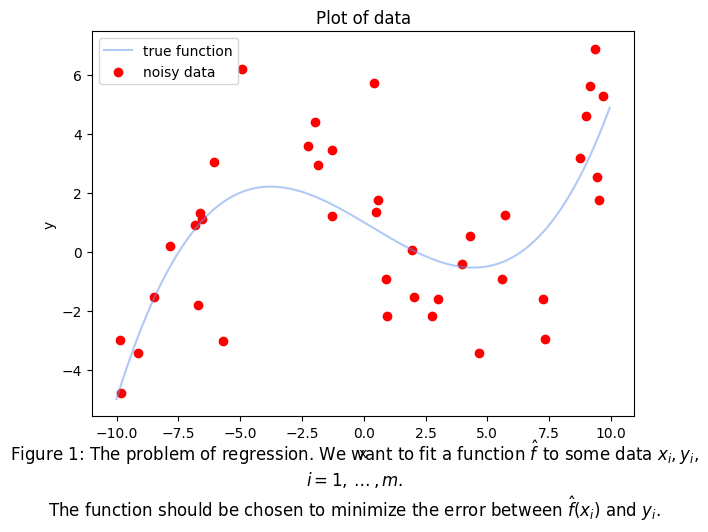

In [ ]:
# Example data
m = 40
np.random.seed(4)

# Define x --> (m, 1)
w0 = np.array([1,-.5,-.01,.01])
x = 20*np.random.random((m,1)) - 10
y = w0[0] + w0[1]*x + w0[2]*(x**2) + w0[3]*(x**3) + 2*np.random.randn(m,1)

fig, ax = plt.subplots(1, 1, figsize = (7, 5))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Plot of data")

# generate continuous curve for the plot
xx = np.arange(-10,10,0.05)
fx = w0[0] + w0[1]*xx + w0[2]*(xx**2) + w0[3]*(xx**3)
ax.plot(xx, fx, label = "true function", color = "cornflowerblue", alpha = 0.5)
ax.scatter(x, y, label = "noisy data", color = "red")

plt.legend()

caption = "Figure 1: The problem of regression. We want to fit a function $\hat f$ to\
 some data $x_i,y_i$, $i = 1,\dots,m$.\nThe function should be chosen to\
 minimize the error between $\hat{f}(x_i)$ and $y_i$."
plt.figtext(0.5, -0.08, caption, wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

We can express $J$ in matrix notation as

$$J(\ma w) = \|\ma y - \ma \Phi \ma w\|^2$$

where $\ma y = [y_1,y_2,\dots,y_m]^T\in\mathbb R^m$, $\ma w = [w_0,w_1,w_2,w_3]^T\in\mathbb R^n$ ($n = 4$) and

$$\ma \Phi = \left[
\begin{array}{c c c c }
	1 & x_1 &  x_1^2 & x_1^3 \\
	1 & x_2 &  x_2^2 & x_2^3 \\
	\vdots & \vdots  & \vdots & \vdots \\
	1 &  x_m & x_m^2 & x_m^3 \\
\end{array}
\right]$$

is an $m\times n$ matrix, called the \emph{design matrix}. In general we will
have more measurements than parameters: $m >> n$.

We are going to compute the minimum of $J$ using two methods: the normal
equations and the SVD.

## Computing the minimum via the normal equations



We seek for the coefficient vector $\ma w^*$ which minimizes $J$:

$$\ma w^* = \argmin_{\ma w} J(\ma w) = \argmin_{\ma w} \|\ma \Phi \ma w - \ma y\|^2$$

As you saw in class, <font color='red'>if $\ma \Phi^T\ma \Phi$ is invertible</font>, the optimal coefficient vector $\ma w^*$ can be computed from the following equation:

\begin{equation}
\ma w^* = (\ma \Phi^T\ma \Phi)^{-1}\ma \Phi^T \ma y.
\end{equation}

These are the *normal equations*.  Recall that $\Phi\ma w^*$ is the projection of $\ma y$ over
$\text{Im}\ma \Phi$.

<font color='blue'>**TOY EXAMPLE.**

In [ ]:
# Define the number of coefficients to calculate (components of w --> w = (w0, w1, ..., wn))
num_coefficients = 4

# Calculate Phi using x defined above
Phi = np.hstack([x**i for i in range(num_coefficients)]) # hstack horizontally stacks the arrays

In [ ]:
print("Independent variable: \n",x,"\n\nDesign matrix:\n",Phi)

Independent variable: 
 [[ 9.34059678]
 [ 0.94464498]
 [ 9.4536872 ]
 [ 4.29631987]
 [ 3.95457649]
 [-5.67821009]
 [ 9.5254891 ]
 [-9.8753949 ]
 [-4.94035275]
 [-1.30416935]
 [ 5.58765844]
 [-6.04629851]
 [ 7.25986471]
 [ 9.66801354]
 [-6.72315517]
 [ 1.94667888]
 [-9.82027805]
 [-2.26857435]
 [-9.11679884]
 [ 9.13305935]
 [-1.27706706]
 [ 8.97954614]
 [ 5.72611972]
 [ 7.32578597]
 [-6.53669157]
 [-8.50102826]
 [ 2.01485443]
 [-6.64055633]
 [ 4.66760335]
 [-1.8311228 ]
 [ 0.55817647]
 [ 8.75143168]
 [ 0.43392245]
 [-7.83613234]
 [-6.83553186]
 [ 0.90405303]
 [ 0.4880816 ]
 [ 2.75220488]
 [-1.97009113]
 [ 2.99610218]] 

Design matrix:
 [[ 1.00000000e+00  9.34059678e+00  8.72467482e+01  8.14936695e+02]
 [ 1.00000000e+00  9.44644984e-01  8.92354145e-01  8.42957866e-01]
 [ 1.00000000e+00  9.45368720e+00  8.93722017e+01  8.44896839e+02]
 [ 1.00000000e+00  4.29631987e+00  1.84583645e+01  7.93030380e+01]
 [ 1.00000000e+00  3.95457649e+00  1.56386752e+01  6.18443374e+01]
 [ 1.00000000e+00 -5.6

In [ ]:
# Calculate w* using y defined above. First check that $Phi.TPhi$ is invertible.

#Transpose
PhiT = Phi.T
#Inverse
# Compute Phi^T * Phi
PhiT_Phi = PhiT @ Phi

# Check if PhiT_Phi is invertible
if np.linalg.det(PhiT_Phi) != 0:
    PhiT_Phi_inv = np.linalg.inv(PhiT_Phi)  # Compute the inverse
else:
    print("Phi^T * Phi not invertible.")

w_ast = PhiT_Phi_inv @ PhiT @ y # Calculate w* using the normal equation

<font color='red'>**(QUESTION 1.1)** Complete the Python function "polyfit_inv_normal_eq" for computing $\ma w^*$. Follow the comments provided in the code.

In [ ]:
def polyfit_inv_normal_eq(x: np.ndarray,
                          y: np.ndarray,
                          n: int):
    """
    Fits a polynomial of degree n to a sets of samples x and y.
    The polynomial minimizes the sum of squared errors (least squares)
    solving the normal equations.

    :param x: m x 1, points in the x axis where the function is known
    :param y: m x 1, known values of the function at positions in x
    :param n: number of coefficients (degree of the polynomial + 1)

    :return w: n x 1, vector of polynomial coefficients
    :return Phi: m x n, data array
    """
    # Create Phi (design matrix)
    Phi = np.hstack([x**i for i in range(n)])  # Each column corresponds to x^i

    # Solve for w* using the normal equations
    Phi_T_Phi = Phi.T @ Phi
    if np.linalg.det(Phi_T_Phi) != 0:  # Check if Phi.T @ Phi is invertible
        w_ast = np.linalg.inv(Phi_T_Phi) @ Phi.T @ y
    else:
        raise ValueError("Phi.T @ Phi is not invertible.")

    return Phi, w_ast

In [ ]:
Phi, w_ast1 = polyfit_inv_normal_eq(x, y, num_coefficients)
print(f"w*:\n{w_ast1}")

w*:
[[ 1.14284584]
 [-0.70192379]
 [-0.01146992]
 [ 0.01268879]]


Run the following cell to compare check the results, and compare the function estimated from the data with the real one.

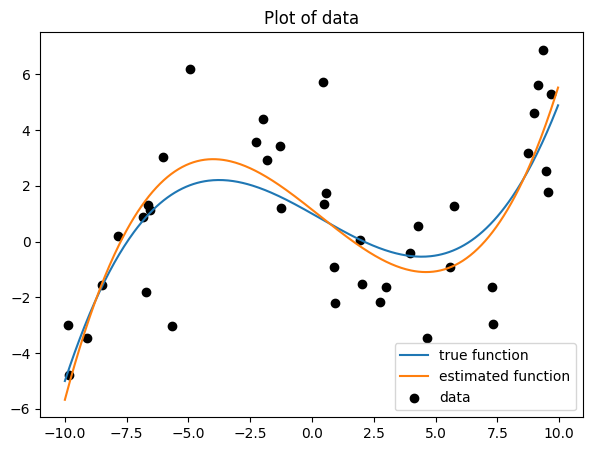

In [ ]:
# generate continuous curve for the plot
xx = np.arange(-10,10,0.05)
fw0 = w0[0] + w0[1]*xx + w0[2]*(xx**2) + w0[3]*(xx**3)
fw_ast = w_ast[0] + w_ast[1]*xx + w_ast[2]*(xx**2) + w_ast[3]*(xx**3)

fig, ax = plt.subplots(1, 1, figsize = (7, 5))
ax.set_title("Plot of data")
ax.plot(xx, fw0, label = "true function")
ax.plot(xx, fw_ast, label = "estimated function")
ax.scatter(x, y, label = "data", color="k")
plt.legend()
plt.show()

The blue function represents the true function, which is the actual relationship between the input `x` and the output `y` as defined by the coefficients `w0`. It is plotted using the continuous curve `fx`.

The orange function represents the estimated function, which is the polynomial approximation of the true function obtained by fitting the data using the normal equations. It is plotted using the continuous curve `fw_ast`.

<font color='blue'>**(QUESTION 1.2)**  Complete the following cell to
verify that the $\ma w^*$ returned by "polyfit_inv_normal_eq" satisfies
that the residue $r = \ma y - \ma \Phi \ma w^*$ is orthogonal to
$\text{Im}\ma \Phi$, \ie $r \perp \text{Im}\ma \Phi$.  Hint:
$\text{Im}\ma \Phi$ is the space generated by the columns of $\ma \Phi$.

In [ ]:
# Calculate the residue
residue = y - Phi @ w_ast1

# Compute the scalar products of the residue with each column of Phi
scalar_products = Phi.T @ residue

print("Scalar product array: \n\n{}\n".format(scalar_products))

# Check if the residue is orthogonal to the columns of Phi
is_orthogonal = np.allclose(scalar_products, 0)
print(f"Residue is orthogonal to the columns of Phi: {is_orthogonal}")


Scalar product array: 

[[1.90958360e-14]
 [3.69482223e-13]
 [2.30926389e-12]
 [3.02549097e-11]]

Residue is orthogonal to the columns of Phi: True


## Minimization with the SVD

Note that, for solving the normal equations using the closed form expression of $\ma w^*$ the matrix $\ma \Phi^T\ma \Phi$ needs to be
invertible. Let us now derive a different way to compute $\ma w^*$ based on
the Singular Value Decomposition (SVD), which can be extended even to the case
in which $\ma \Phi^T\ma \Phi$ is not invertible.  

Using the SVD decomposition, we can express
$$\ma \Phi = U S V^T$$
where $U\in \mathbb R^{m\times m}$ and $V\in \mathbb R^{n\times n}$ are orthogonal
matrices (a square matrix $A\in \mathbb R^{m\times m}$ is orthogonal when $A^T A =
A A^T = I_m$), and $S\in\mathbb R^{m\times n}$ is a rectangular diagonal
matrix. The diagonal values of $S$, $s_{ii} = \sigma_i > 0$, for $i = 1,\dots,q$
are the singular values. The number of singular values $q$ is the rank of $\ma
\Phi$, thus, $q \leqslant \min \{m,n\}$.

We will use the SVD to compute the \emph{pseudo-inverse} of $\ma \Phi$, $\ma
\Phi^\dagger$. Let us first recall what is the pseudo-inverse of a matrix, and
how it is computed.

### The Pseudo-inverse

We will define define pseudo-inverse in two steps: first we are going to define
the pseudo-inverse of a diagonal matrix. Then we are going to extend this
definition to any matrix.


*Pseudo-inverse of a diagonal matrix.* Let $S$ be an $m\times
n$ rectangular diagonal matrix. The pseudo-inverse of $S$, $S^\dagger$,
is also a diagonal matrix, but with dimensions $n\times m$. The diagonal elements
of $S^\dagger$ are computed as follows

$$s^\dagger_{ii} = \left\{
\begin{array}{l l}
	s_{ii}^{-1} & \text{if }s_{ii} \neq 0\\
	0 & \text{if }s_{ii} = 0,
\end{array}
\right.$$

for $i = 1,\dots, \min(m,n)$.

*Pseudo-inverse of any matrix.* Let $A$ be an $m\times n$
matrix. We define its pseudo-inverse based on the SVD decomposition and
the previous definition of the pseudo-inverse of a diagonal matrix. Using the
SVD decomposition we can express $A = USV^T$. We then define

$$A^\dagger = VS^\dagger U^T.$$

Note that $S$ is a diagonal matrix with the singular values on the diagonal, so
we already know how to compute its pseudo-inverse.

We will generate a random matrix to work with it in the following cells.

In [ ]:
# generate 5×3 random matrix of type np.ndarray
np.random.seed(4)
A = np.random.randint(-5, 3+1, (5,3)) ### WRITE YOUR SOLUTION
print(A)

[[ 2  0 -4]
 [ 3  2  3]
 [-3  2  2]
 [ 2  3 -1]
 [-3  1 -1]]


<font color='blue'>**(QUESTION 1.3)**  Generate a $5\times 3$ random matrix, $A$. Compute its
SVD $A = USV^T$ using the command "svd". Verify that the $U$ and $V$ are
orthogonal matrices and $S$ is diagonal. Verify that $A = USV^T$.

In [ ]:
# Compute its SVD
U, S, Vt = np.linalg.svd(A)

# Convert the singular values vector into a diagonal matrix
S = np.diag(S)
S = np.vstack([S, np.zeros((2, 3))]) # Add zeros to the diagonal matrix to match the shape of A

# Print the results
print("U: \n\n{}\n\nS: \n\n{}\n\nVt: \n\n{} \n".format(U, S, Vt))

# Reconstruct the original matrix A using SVD tocheck if we did it right
A_reconstructed = U @ S @ Vt
print("Reconstructed A: \n{}".format(A_reconstructed))

U: 

[[-0.63227163  0.34429083  0.29062729 -0.6124131  -0.14893753]
 [-0.12462705 -0.82121584  0.0056757  -0.41939076  0.36626743]
 [ 0.60182985 -0.14479747  0.4320703  -0.36522028 -0.54476043]
 [-0.34189018 -0.28160621  0.69383736  0.55409126 -0.12402277]
 [ 0.32498096  0.32680271  0.49740179 -0.0930517   0.72905432]]

S: 

[[6.12349003 0.         0.        ]
 [0.         5.6353806  0.        ]
 [0.         0.         3.83996815]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]

Vt: 

[[-0.83328905  0.04143324  0.55128273]
 [-0.51181885 -0.43476079 -0.74096189]
 [-0.20897567  0.89959232 -0.38348772]] 

Reconstructed A: 
[[ 2.00000000e+00  4.17478897e-17 -4.00000000e+00]
 [ 3.00000000e+00  2.00000000e+00  3.00000000e+00]
 [-3.00000000e+00  2.00000000e+00  2.00000000e+00]
 [ 2.00000000e+00  3.00000000e+00 -1.00000000e+00]
 [-3.00000000e+00  1.00000000e+00 -1.00000000e+00]]


In [ ]:
#Verify that U and V are orthioigonal
UTU = U.T @ U  # Compute U^T * U
UUT = U @ U.T  # Compute U * U^T
VTV = Vt @ Vt.T  # Compute V^T * V
VVT = Vt.T @ Vt  # Compute V * V^T

print("UTU\n\n{}\n\nUUT\n\n{}\n\nVTV\n\n{}\n\nVVT\n\n{}\n\nAre U and V orthogonal matrices? {}".format(UTU,UUT,VTV,VVT,np.allclose(UTU,UUT) and np.allclose(VTV,VVT)))


UTU

[[ 1.00000000e+00  6.85121928e-17  1.62679415e-17  2.72663512e-16
   1.00440847e-16]
 [ 6.85121928e-17  1.00000000e+00  5.35681350e-19 -1.65934674e-17
  -1.78283933e-16]
 [ 1.62679415e-17  5.35681350e-19  1.00000000e+00 -6.76978252e-17
   1.28943400e-17]
 [ 2.72663512e-16 -1.65934674e-17 -6.76978252e-17  1.00000000e+00
   3.49218546e-17]
 [ 1.00440847e-16 -1.78283933e-16  1.28943400e-17  3.49218546e-17
   1.00000000e+00]]

UUT

[[ 1.00000000e+00  8.71687771e-17 -2.11442358e-16 -3.46455757e-17
  -3.06933091e-16]
 [ 8.71687771e-17  1.00000000e+00 -8.53389455e-17  8.88963096e-17
  -5.81780329e-17]
 [-2.11442358e-16 -8.53389455e-17  1.00000000e+00 -2.52642008e-16
   1.36310639e-16]
 [-3.46455757e-17  8.88963096e-17 -2.52642008e-16  1.00000000e+00
  -1.81898767e-16]
 [-3.06933091e-16 -5.81780329e-17  1.36310639e-16 -1.81898767e-16
   1.00000000e+00]]

VTV

[[ 1.00000000e+00 -1.43174903e-16  1.86819073e-19]
 [-1.43174903e-16  1.00000000e+00 -7.65937103e-17]
 [ 1.86819073e-19 -7.65937103

<font color='blue'>**(QUESTION 1.4a)** Compute the pseudo-inverse of $S$, $S^\dagger$. Use it
to compute the pseudo-inverse of $A$, $A^\dagger$. Verify that $A^\dagger A$
is the identity matrix of size $3$.

In [ ]:
# Compute pseudo-inverse of S
for j in range(S.shape[1]):
    S[j, j] = 1 / S[j, j]

S_pinv = S.T
print(S_pinv)

[[0.16330557 0.         0.         0.         0.        ]
 [0.         0.1774503  0.         0.         0.        ]
 [0.         0.         0.26041883 0.         0.        ]]


In [ ]:
# Compute pseudo-inverse of A
A_pinv = Vt.T @ S_pinv @ U.T
print(A_pinv)

[[ 0.03895438  0.09123526 -0.09226038  0.03434136 -0.10097386]
 [ 0.03724586  0.0638419   0.11646449  0.18195797  0.0935133 ]
 [-0.13121476  0.09618999  0.03007005 -0.06304459 -0.0633863 ]]


In [ ]:
# Verify that A†A is the identity matrix of size 3 of type np.ndarray
I_ = A_pinv @ A
print("A†A:\n\n{}\n".format(I_))
print("A†A is the identity matrix of size 3?: {}".format(np.allclose(I_, np.identity(n = len(I_)))))

A†A:

[[ 1.00000000e+00  9.71445147e-17  1.38777878e-17]
 [ 2.08166817e-16  1.00000000e+00  2.63677968e-16]
 [-2.77555756e-17  2.63677968e-16  1.00000000e+00]]

A†A is the identity matrix of size 3?: True


<font color='blue'>**(QUESTION 1.4b)** What happens with $AA^\dagger $?

In [ ]:
# Verify that AA† is the identity matrix of size 3 of type np.ndarray
I_ = A @ A_pinv
print("A†A:\n\n{}\n".format(I_))
print("A†A is the identity matrix of size 3?: {}".format(np.allclose(I_, np.identity(n = len(I_)))))

A†A:

[[ 0.60276781 -0.20228942 -0.30480096  0.3208611   0.05159747]
 [-0.20228942  0.68995956  0.04635799  0.27780625 -0.30605388]
 [-0.30480096  0.04635799  0.56985022  0.13480267  0.36317558]
 [ 0.3208611   0.27780625  0.13480267  0.67760123  0.14197847]
 [ 0.05159747 -0.30605388  0.36317558  0.14197847  0.45982117]]

A†A is the identity matrix of size 3?: False


<font color='red'>**ANSWER:**

The consequence that makes that $A^\dagger A$ acts as the identity matrix and $AA^\dagger $ does not end in it, is their ranks.
$A^\dagger A$ is a nxn matrix with rank n and n independent columns, whereas $AA^\dagger $ is a mxm that when m>n it makes that the rank of $AA^\dagger $ is automatically at most n so it cannot be invertible. In this case we are working with a matrix A that is 5x3 so m>n therefore $AA^\dagger $ is not invertible and does not equal the identity matrix.

### Solving least squares with the pseudo-inverse

It turns out that we can compute the solution $\ma w^*$ to the least squares
problem using the pseudo-inverse of the design matrix $\ma \Phi$ as follows:

$$\ma w^* = \ma \Phi^{\dagger}\ma y = VS^\dagger U^T\ma y.$$

<font color='blue'>**(QUESTION 1.5)** Complete the Python function "polyfit_svd_normal_eq" for computing $\ma w^*$. Follow the comments provided in the code.


In [ ]:
def polyfit_svd_normal_eq(x: np.ndarray,
                          y: np.ndarray,
                          n: int):
    """
    Fits a polynomial of degree n to a sets of samples x and y. The polynomial minimizes the sum
    of squared errors (least squares) using the pseudoinverse of data array.

    :param x: m x 1, points in the x axis where the function is known
    :param y: m x 1, known values of the function at positions in x
    :param n: number of coefficients (degree of the polynomial + 1)

    :return w_ast: n x 1, vector of polynomial coefficients
    :return Phi_pinv: n x m, pseudo-inverse of Phi
    :return Phi: m x n, data array
    """
    # TODO: Calculate Phi
    Phi = np.hstack([x**i for i in range(n)])  # Each column corresponds to x^i

    # TODO: Calculate its SVD
    U, S, Vt = np.linalg.svd(Phi)

    # TODO: Calculate the pseudo-inverse of S
    S = np.diag(S)
    for j in range(S.shape[1]):
            S[j, j] = 1 / S[j, j]

    S = np.vstack([S, np.zeros((m-n, n))])
    S_pinv = S

    # TODO: Calculate w*
    Phi_pinv = Vt.T @ S_pinv.T @ U.T
    w_ast = Phi_pinv @ y

    return Phi, Phi_pinv, w_ast

In [ ]:
Phi, Phi_pinv, w_ast2 = polyfit_svd_normal_eq(x, y, num_coefficients)
print(f"w*:\n{w_ast2}")

w*:
[[ 1.14284584]
 [-0.70192379]
 [-0.01146992]
 [ 0.01268879]]


In [ ]:
Phi, Phi_pinv, w_ast2 = polyfit_svd_normal_eq(x, y, num_coefficients)

<font color='blue'>**(QUESTION 1.6)** Compare with the solution obtained by inverting the
normal equations.

In [ ]:
print(f"Solution is similar with inverting normal equations: {np.allclose(w_ast1, w_ast2)}")

Solution is similar with inverting normal equations: True


# Part 2: Principal Components Analysis

In this section we are going to explore the application of Principal Components
Analysis (PCA) for *dimensionality reduction*. Imagine we have a data set
formed by several (say $m$) points in $\mathbb R^n$, $\mathcal X =
\{x_1,\dots,x_m\}$. For example, in Figure 2 below we show a set of
points in $\mathbb R^2$. Another example, in the following section, the
"points" will be $m$ images of faces. Since the points are in $\mathbb R^n$
we are using $n$ coefficients to represent them. In many cases, we would be
interested in finding a representation of the dataset, which allows to encode
each point $x_i$ using $p << n$ coefficients.

Let us assume for simplicity that the points are centered at the origin (\ie
the mean or barycenter is at the origin: $\sum_i x_i = 0$). The idea behind PCA
is to approximate the point set by projecting it on a $p$ dimensional subspace
$V_p$, with $p \leqslant n$.

<figure>
  <img src="https://github.com/Muchay/OptTechCourse_Aux/blob/main/Lab1/images/PCA_img.png?raw=true" width="50%">
  <figcaption>Figure 2: PCA of a two dimensional point set. The principal directions $v_1,v_2$ form an orthogonal basis of $R^2$. Note that $v_1$ "aligns" with the point set: most of the variation of the points is along the direction $v_1$. These directions are chosen to minimize the mean squared projection error. In the Figure we show the projection errors over the principal direction $v_1$ for two points (red lines).</figcaption>
</figure>

To do that, we will build an orthonormal basis $\mathcal V_n =
\{v_1,v_2,\dots,v_n\}$ of $\mathbb R^n$, specially designed to adapt to the dataset (these
are the red vectors $v_1,v_2$ in Figure 2).

Any point $x_i$ from the data set can be expressed by its $n$ coordinates
on the basis:
$[\langle x_i,v_1\rangle,\dots,\langle x_i,v_n\rangle]^T\in\mathbb R^n$.  This means that we
can recover $x_i$ as
$$x_i = \sum_{j = 1}^n \langle x_i,v_j\rangle v_j.$$
If we only keep the first $p$ coefficients $[\langle x_i,v_1\rangle,\dots,\langle
x_i,v_p\rangle]^T$, we recover the projection of $x_i$ over $V_p$, the subspace
spanned by the first $p$ vectors in the basis:

$$P_{V_p} (x_i) = \sum_{j = 1}^p
\langle x_i,v_j\rangle v_j.$$

What we want to find is a basis that best approximates the dataset. Meaning that
for each $p \leqslant n$, $V_p$ is the $p$-dimensional vector space minimizing
the mean squared projection error

$$\frac1m\sum_{i = 1}^m \|P_{V_p}(x_i) - x_i\|^2.$$

The resulting vectors $v_1,\dots,v_n$ are called the principal
directions of the set of points $\mathcal X= \{x_1,\dots,x_m\}$. For any
$x\in \mathbb R^n$, the coefficients $\langle x,v_1\rangle,\dots,\langle
x,v_n\rangle$ are called the principal components of $x$.

## Computation and Properties of the Principal Components

<font color='blue'>**TOY EXAMPLE.**

Let us consider a data set $ \mathcal X = \{x_1,\dots,x_m\}\subset \mathbb R^n $.
Let $ \ma X $ be the data matrix: the rows of $ \ma X $ are the vectors $ x_i\in
\mathcal X $.

* The principal directions of $ \mathcal X $ form an orthonormal basis
$ v_1,\dots,v_n $ of $ \mathbb R^n $ given by the eigenvectors of the
empirical covariance matrix $ C = \frac1{m-1}\ma X^T\ma X $, where $ \ma X $ is a matrix that contains the points $ x_i $ as rows. Before computing the matrix $ X $, we need to center the points. Let $ \lambda_1\geqslant
\lambda_2\geqslant \dots \geqslant \lambda_n \geqslant 0 $ be the
corresponding eigenvalues.

In [ ]:
# We generate 5 random points in IR^3, and store them as the rows in X
# Define x --> (m, n)
m, n = 5, 3
x = np.random.random((m,n))
print("X: \n\n{}\n".format(x))

# Calculate its mean
mu = np.mean(x, axis=0) # mean of each column (axis=0)
print("Mean: {}\n".format(mu))

# Center X
x_centered = x - mu # Center the data by subtracting the mean
print("X centered: \n\n{}\n".format(x_centered))

# Check data is well centered (sum of rows should be 0)
print("Sum of rows: \n\n{}\n".format(np.sum(x_centered, axis=0).sum()))


X: 

[[0.98340068 0.16384224 0.59733394]
 [0.0089861  0.38657128 0.04416006]
 [0.95665297 0.43614665 0.94897731]
 [0.78630599 0.8662893  0.17316542]
 [0.07494859 0.60074272 0.16797218]]

Mean: [0.56205886 0.49071844 0.38632178]

X centered: 

[[ 0.42134181 -0.3268762   0.21101216]
 [-0.55307277 -0.10414716 -0.34216172]
 [ 0.3945941  -0.05457179  0.56265552]
 [ 0.22424712  0.37557086 -0.21315636]
 [-0.48711028  0.11002428 -0.2183496 ]]

Sum of rows: 

-6.106226635438361e-16



In [ ]:
# Calculate the empirical covariance matrix of type np.ndarray
C = (1/(m-1)) * (x_centered.T @ x_centered)
print("Covariance matrix: \n\n{}".format(C))

Covariance matrix: 

[[ 0.23167153 -0.01775816  0.13968244]
 [-0.01775816  0.06845789 -0.04203097]
 [ 0.13968244 -0.04203097  0.14282355]]


In [ ]:
# Define the number of p principal directions to be kept
p = n #TRY WITH p=n

# Compute the principal directions, sort them by lambda values (eigen values) and return only
# the p-first values


# Compute eigen values and vectors
eigen_values, eigen_vectors =  np.linalg.eig(C) ### WRITE YOUR SOLUTION

print(eigen_values)

eigen_values = eigen_values[:p]
eigen_vectors =  eigen_vectors[:p]

# 2. Sort the eigenvalues (and eigenvectors accordingly!!) and return only the p-first values
eigen_values = np.sort(eigen_values)[::-1] # Sort in descending order
eigen_vectors =  eigen_vectors[:, np.argsort(eigen_values)[::-1]] # Sort eigenvectors accordingly

[0.33951587 0.07743218 0.02600492]


In [ ]:
print("Eigen values: \n\n{}\n\nEigen vectors: \n\n{}".format(eigen_values, eigen_vectors))

Eigen values: 

[0.33951587 0.07743218 0.02600492]

Eigen vectors: 

[[-0.79206592  0.41786422 -0.4449956 ]
 [ 0.14388049  0.83623825  0.52915403]
 [-0.59323688 -0.35509869  0.72247833]]


*   For $p = 1,\dots,n$, the subspace $V_p$ spanned by the first $p$
principal directions is the $p$-dimensional subspace which minimizes the
mean squared projection error:

$$\frac1m\sum_{i = 1}^m \|x_i - P_{V_p}(x_i)\|^2 = \sum_{j = p+1}^n \lambda_j.$$

*   Equivalently $V_p$ is also the $p$-dimensional subspace that maximizes the
projection variance:

$$\frac1m\sum_{i = 1}^m \| P_{V_p}(x_i)\|^2 = \sum_{j = 1}^p \lambda_j$$

In [ ]:
# Calculate the projection variance
proj_var = sum(eigen_values)
print("Projection variance: \n\n{}".format(proj_var))

Projection variance: 

0.4429529699461729


<font color='blue'>**(QUESTION 2.1)** Complete the Python function "pca_prin_dir" for
computing the $p$ first principal directions via the eigenvectors of $\frac1{m-1}\ma X^T\ma X$.  Follow the comments in the code. You should be able to reuse the computations that you did in the previous cells.






In [ ]:
def pca_prin_dir(x: np.ndarray,
                 p: int):
    """
    Computes the principal directions, variances and mean of vectors in x.
    x is a row data array: its rows are vectors xi. The principal directions are given
    by eigenvectors of the empirical covariance matrix, x'*x.

    :param x: row data array, m x n
    :param p: number of principal directions

    :return eigen_vectors: principal direction array (each column is a PD) n x p
    :return eigen_values: eigenvalue diagonal array p x p
    :return mu: mean
    """
    m, n = x.shape

    # TODO: Calculate the mean of the incoming data and center x
    mu = np.mean(x)
    x_centered = x - mu

    # TODO: Calculate the empirical covariance matrix
    C = (1/(m-1)) * (x_centered.T @ x_centered)
    print("Covariance matrix: \n\n{}".format(C)) # same formula as before and print to check for correct computation

    # TODO: Compute the principal directions and sort them by lambda values (eigen values) and return only
    # the p-first values
    # 1. Get the eigen values and vectors
    eigen_values, eigen_vectors = np.linalg.eig(C)

    # 2. Sort them by eigen values and return only the p-first values
    eigen_values = eigen_values[:p]
    eigen_vectors =  eigen_vectors[:p]
    eigen_values = np.sort(eigen_values)[::-1]
    eigen_vectors =  eigen_vectors[:, np.argsort(eigen_values)[::-1]]
    eigen_values = np.diag(eigen_values) # Add zeros to the diagonal matrix to match the shape of A


    return eigen_vectors, eigen_values, mu

In [ ]:
eigen_vectors, eigen_values, mu = pca_prin_dir(x, p)
print("Eigen values: \n\n{}\n\nEigen vectors: \n\n{}\n\nMean: \n\n{}".format(eigen_values, eigen_vectors, mu))

Covariance matrix: 

[[ 0.24015032 -0.01662379  0.13006928]
 [-0.01662379  0.06860966 -0.0433171 ]
 [ 0.13006928 -0.0433171   0.15372284]]
Eigen values: 

[[0.33960709 0.         0.        ]
 [0.         0.08663165 0.        ]
 [0.         0.         0.03624408]]

Eigen vectors: 

[[-0.79495116  0.49199541 -0.35495518]
 [ 0.14300474  0.72056185  0.6784838 ]
 [-0.58957807 -0.48860121  0.64316915]]

Mean: 

0.47969969468354257


<font color='blue'>**(QUESTION 2.2)** Complete the Python functions "pca_prin_comp" for
computing the $p$ first principal components $[\langle x,v_i \rangle]_{i =
1,\dots,p}$ of a point $x$.

In [ ]:
def pca_prin_comp(x: np.ndarray,
                  eigen_vectors: np.ndarray,
                  mu: np.ndarray = None):
    """
    Computes the principal components of vectors in x. x is a row data array: its rows are vectors xi.
    The principal components zi of a vector xi are given by the projection over the principal directions:

                            zi = [ <xi-mu,v1> <xi-mu,v2> ... <xi-mu,vp> ]

    :param x: row data array, m x n
    :param eigen_vectors: principal direction array (each column is a PD) n x p

    :return z : m x p, principal component array. Row i contains the princpal components of xi
    """
    # TODO: Calculate the raw data mean along row axis and center x
    if mu is None:
        mu = np.mean(x, axis=0)



    x_centered = x - mu

    # Project x over basis elements to compute principal components
    z = x_centered @ eigen_vectors

    return mu, z

In [ ]:
mu, z_p = pca_prin_comp(x = x, eigen_vectors = eigen_vectors)
print("Mean: \n\n{}\n\nPrincipal components: \n\n{}".format(mu, z_p))

Mean: 

[0.56205886 0.49071844 0.38632178]

Principal components: 

[[-0.50609915 -0.13133708 -0.23562115]
 [ 0.62650335 -0.17997309 -0.09441398]
 [-0.65321642 -0.12009804  0.18479338]
 [ 0.00111522  0.48509904  0.03812547]
 [ 0.53169701 -0.05369084  0.10711628]]


<font color='blue'>**(QUESTION 2.3)** Complete the Python functions "pca_reconstruct" for
reconstructing a point $x$ from its principal components.

In [ ]:
def pca_reconstruct(z: np.ndarray([]),
                    eigen_vectors: np.ndarray([]),
                    mean: float):
    """
    Given a set of vectors z(i,:) (rows of array z) expressed in principal components, this function computes the x(i,:), 'inverting' the PCA change of coordinates.
    It goes from the low dimensional PCA representation to the high dimensional vectors.

    :param z: m x p, principal component array (row-wise).
    :param V: principal direction array (each column is a PD) n x p
    :param mu: mean

    :return x: row data array, m x n. Row x(i,:) is the high dimensional reconstruction from z(i,:)
    """
    # Calculate x_hat
    x_hat = z @ eigen_vectors.T # Project z over the basis elements to compute x_hat

    # Add the mean to recover the real array values
    x_ = x_hat + mean

    return x_

In [ ]:
pca_reconstruct(z = z_p, eigen_vectors = eigen_vectors, mean = mu)

array([[0.98340068, 0.16384224, 0.59733394],
       [0.0089861 , 0.38657128, 0.04416006],
       [0.95665297, 0.43614665, 0.94897731],
       [0.78630599, 0.8662893 , 0.17316542],
       [0.07494859, 0.60074272, 0.16797218]])

## Example with a dataset

First we need some helper files:

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Move to your drive
%cd /content/drive/MyDrive/
%mkdir tmp
%cd tmp

/content/drive/MyDrive
mkdir: cannot create directory ‘tmp’: File exists
/content/drive/MyDrive/tmp


In [ ]:
# Clone repo with auxilary files required for this and the following labs.
# This needs to be done only once for the course.
!git clone https://github.com/Muchay/OptTechCourse_Aux.git

fatal: destination path 'OptTechCourse_Aux' already exists and is not an empty directory.


In [ ]:
# Create source path
source = "/content/drive/MyDrive/tmp/OptTechCourse_Aux/Lab1/"

Next, we install and import required libraries, and import the dataset.

**1) Read the CSV file which contains the data and plot them**

In [ ]:
# Import Pandas --> see https://pandas.pydata.org/
import pandas as pd

In [ ]:
# Read the file
data = pd.read_csv(source+"data/point_cloud_r3.csv", sep = ",", header=None, names = ["x", "y", "z"])
data.head()

,x,y,z
0,2.09450,3.2207,0.26258
1,4.11370,4.4256,-0.27051
2,0.48331,1.9079,-3.02970
3,4.57860,8.9463,-8.50280
4,0.29102,1.3979,-0.26870


In [ ]:
import plotly.graph_objects as go

m = len(data['x'])
fig = go.Figure(data=[go.Scatter3d(x=data['x'],
                                   y=data['y'],
                                   z=data['z'], mode='markers',
                                   marker = dict(size=2,
                                                 color=np.arange(m),
                                                 opacity=.5
                                                 )
                                   )])

fig.show()

:**2) Compute principal all principal directions and the corresponding eigenvalues**

NOTE: in this example we are going to do some visualization of the principal components in IR^3. For that we will compute ALL principal directions and ALL principal components. Please note that this is not the typical way in which PCA is used. In a normal application of dimensionality reduction we would compute only a few principal directions and principal components

In [ ]:
# Define the number of principal directions
p = len(data.columns)

# Calculate the PCA principal directions for the given data
eigen_vectors, eigen_values, mu = pca_prin_dir(data.values, p)
print("Eigen values: \n\n{}\n\nEigen vectors: \n\n{}".format(eigen_values, eigen_vectors))

Covariance matrix: 

[[ 3.0052618   3.92216505 -1.80102035]
 [ 3.92216505  7.06399191 -5.81985401]
 [-1.80102035 -5.81985401 17.0232516 ]]
Eigen values: 

[[20.34051461  0.          0.        ]
 [ 0.          6.30745903  0.        ]
 [ 0.          0.          0.44453166]]

Eigen vectors: 

[[-0.19086371 -0.8064906   0.55959266]
 [-0.44084787  0.57977329  0.68521243]
 [ 0.87705427  0.11591305  0.46619735]]


<font color='blue'>**(QUESTION 2.4a)** What can you tell from the eigenvalues about the geometry of the dataset?

<font color='red'>**ANSWER:**

Because one eigenvalue is much larger than the others, especially compared to the third, in practical terms, this means that most of the variation in the data can be explained using only two directions. As a result, the data points are not uniformly spread throughout the 3D space but are concentrated in a plane defined by the largest eigenvalues.

<font color='blue'>**(QUESTION 2.4b)** Which is the number of components you would keep to hold at least the 95% of the variance?

In order to answer this question, we must represent the explained variance in terms of participation.

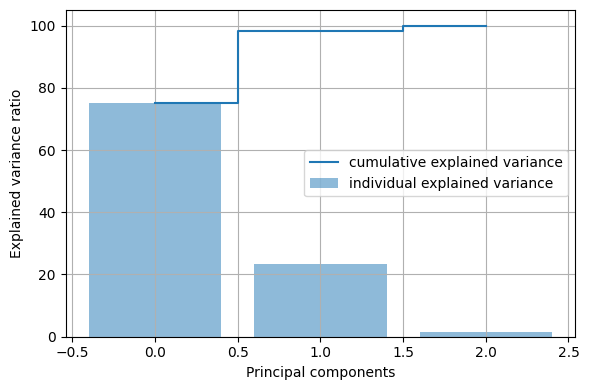

In [ ]:
# In order to be able to answer to this question we had to debug a couple of issues with the given code
# involving the creation of var_exp and the plot where the range had to be changed.

# Calculate the participation in terms of %
tot = sum(np.diag(eigen_values)) # sum the diagonal values (eigenvalues) of the eigen_values matrix to get a single number representing the total sum of eigenvalues
var_exp = [(i / tot)*100 for i in sorted(np.diag(eigen_values), reverse=True)]
cum_var_exp = np.cumsum(var_exp)

# Plot the graphic
plt.figure(figsize=(6, 4))

plt.bar(range(len(var_exp)), var_exp, alpha=0.5, align='center', # var_exp contains the individual explained variances for each principal component, and its length corresponds to the number of principal components considered.
        label='individual explained variance')
plt.step(range(len(var_exp)), cum_var_exp, where='mid', #var_exp contains the individual explained variances for each principal component, and its length corresponds to the number of principal components considered.
          label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()
plt.grid()
plt.show()

<font color='red'>**ANSWER:**

We should keep 2 components, since the cumulative explained variance after the second component exceeds 95%.

<font color='blue'>**(QUESTION 2.4c)** How large would be the mean projection error we would commit by keeping only the first principal component?

In theory, MSE and eigenvalues are related by the following equation:

\begin{equation*}
\frac{1}{m}\sum^{n}_{i=1}\|x_{i}-P_{V_{p}}(x_{i})\|^{2}= \sum^{n}_{j=p+1}\lambda_{j}
\end{equation*}

Therefore, we will check that in both cases we achieve the same result.

In [ ]:
# Define the number of components to be kept
components = 2
components_array = list(range(components))

# Calculate the projection of x over the eigenvectors basis by only keeping the first component
mu, z = pca_prin_comp(x = data.values,
                      eigen_vectors = eigen_vectors)
projection = pca_reconstruct(z = z[:, components_array], eigen_vectors = eigen_vectors[:, components_array], mean = mu)

# Calculate the MSE
print("MSE for the first {} components: {}".format(components, np.power(data.values - projection, 2).sum() / (len(data) - 1)))

MSE for the first 2 components: 6.022555716457802


**Function definition**

In [ ]:
def calculate_projection_mse(x: np.ndarray,
                             eigen_vectors: np.ndarray,
                             z: np.ndarray,
                             p: np.ndarray,
                             mean: float):
    """
    Calculates the projection MSE

    :param x: row data array, m x n
    :param eigen_vectors: principal direction array (each column is a PD) n x p
    :param z: m x p, principal component array. Row i contains the princpal components of xi
    :param p: number of components to be used when projecting
    :param mu: mean

    :return:
    """
    # Define the number of components to be kept
    components_array = list(range(p))

    # Calculate the projection of x over the eigenvectors basis by only keeping the first component
    mu, z = pca_prin_comp(x = x, eigen_vectors = eigen_vectors)
    projection = pca_reconstruct(z = z[:, components_array], eigen_vectors = eigen_vectors[:, components_array], mean = mean)

    # Calculate the MSE
    mse = np.power(x - projection, 2).sum() / (len(x) - 1)

    return mse

In [ ]:
components = 1
print("MSE for the first {} components: {}".format(components, calculate_projection_mse(x = data.values,
                                                                                        eigen_vectors = eigen_vectors,
                                                                                        z = z,
                                                                                        p = components,
                                                                                        mean = mu)))

MSE for the first 1 components: 6.466244761949248


<font color='red'>**ANSWER:**

By keeping one component the mean projection error would be 6.466.

<font color='blue'>**(QUESTION 2.4d)** And if we keep the first and the second?

In [ ]:
components = 2
print("MSE for the first {} components: {}".format(components, calculate_projection_mse(x = data.values,
                                                                                        eigen_vectors = eigen_vectors,
                                                                                        z = z,
                                                                                        p = components,
                                                                                        mean = mu)))

MSE for the first 2 components: 6.022555716457802


<font color='red'>**ANSWER:**

Then it would be 6.0225.

**3) Now plot the point cloud in 3D. Do three plots, in each of them will color the points with the value of one principal component (use the provided function plot_3d_and_components). Also plot the principal directions as vectors at the origin. The length of these vectors is proportional to the corresponding eigenvalue lambda.**

In [ ]:
def plot_3d_and_projections(xs: np.ndarray,
                            ys: np.ndarray,
                            zs: np.ndarray,
                            xp: np.ndarray,
                            yp: np.ndarray,
                            zp: np.ndarray,
                            title: str = ""):
    """
    Plots a 3D graph and the PCA components

    :param xs: x-axis data
    :param ys: y-axis data
    :param zs: z-axis data
    :param xp: x-axis projection data
    :param yp: y-axis projection data
    :param zp: z-axis projection data
    """
    # Import libraries
    import plotly.graph_objects as go

    fig = go.Figure(data=[go.Scatter3d(x=xs, y=ys, z=zs, mode='markers',
                                       marker = dict(size=2, opacity=.5))])
    fig.add_traces(data=go.Scatter3d(x=xp, y=yp, z=zp, mode='markers',
                                     marker = dict(size=2, opacity=.5)))
    fig.show()

In [ ]:
# Plot the point cloud in 3D with the first principal component
plot_3d_and_projections(xs=data['x'], ys=data['y'], zs=data['z'],
                        xp=z[:, 0] * eigen_vectors[0, 0],
                        yp=z[:, 0] * eigen_vectors[1, 0],
                        zp=z[:, 0] * eigen_vectors[2, 0],
                        title="First Principal Component")

# Plot the point cloud in 3D with the second principal component
plot_3d_and_projections(xs=data['x'], ys=data['y'], zs=data['z'],
                        xp=z[:, 1] * eigen_vectors[0, 1],
                        yp=z[:, 1] * eigen_vectors[1, 1],
                        zp=z[:, 1] * eigen_vectors[2, 1],
                        title="Second Principal Component")

# Plot the point cloud in 3D with the third principal component
plot_3d_and_projections(xs=data['x'], ys=data['y'], zs=data['z'],
                        xp=z[:, 2] * eigen_vectors[0, 2],
                        yp=z[:, 2] * eigen_vectors[1, 2],
                        zp=z[:, 2] * eigen_vectors[2, 2],
                        title="Third Principal Component")

**4) Now let's do some dimensionality reduction. For that, we keep some of theprincipal components z.**

**a) Keep the first two principal components, project the points into a two dimensional vector space and calculate the projection error.**

**First and second components**

In [ ]:
# Calculate the projection of x over the eigenvectors basis by only keeping the first and second components
components_array = [0, 1]
mu, z = pca_prin_comp(x = data.values,
                      eigen_vectors = eigen_vectors)
projection = pca_reconstruct(z = z[:, components_array], eigen_vectors = eigen_vectors[:, components_array], mean = mu)
error_projection_fs = np.sqrt(np.power(data.values - projection, 2).sum(axis = 1))

# Plot the projection
plot_3d_and_projections(xs = data.x,
                        ys = data.y,
                        zs = data.z,
                        xp = projection[:, 0],
                        yp = projection[:, 1],
                        zp = projection[:, 2],
                        title = "Real data versus projection over the first and second components")

**b) Keep the first and third principal components, project the points into a two dimensional vector space and calculate the projection error.**

In [ ]:
# Calculate the projection of x over the eigenvectors basis by only keeping the first and second components
components_array = [0, 2]
mu, z = pca_prin_comp(x = data.values,
                      eigen_vectors = eigen_vectors)
projection = pca_reconstruct(z = z[:, components_array], eigen_vectors = eigen_vectors[:, components_array], mean = mu)
error_projection_ft = np.sqrt(np.power(data.values - projection, 2).sum(axis = 1))

# Plot the projection
plot_3d_and_projections(xs = data.x,
                        ys = data.y,
                        zs = data.z,
                        xp = projection[:, 0],
                        yp = projection[:, 1],
                        zp = projection[:, 2],
                        title = "Real data versus projection over the first and third components")

**5) Plot the low dimensional representative z in IR^2 and color them with the projection error. Look at the colorbars to compare the error in both plots.**

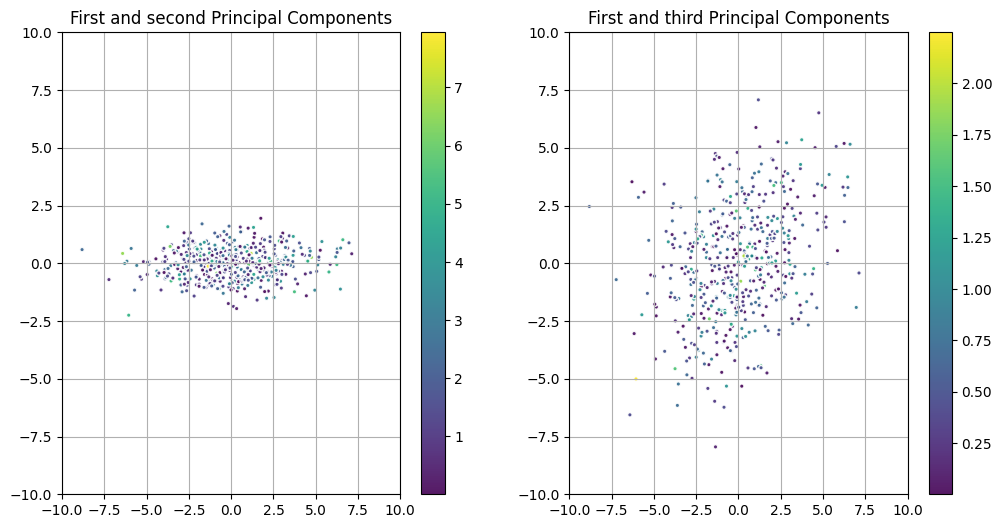

In [ ]:
fig, (ax1, ax2) = plt.subplots(figsize=(12, 6), ncols=2)
sc = ax1.scatter(z[:, 0] , z[:, 1], s=10, c = error_projection_fs, alpha=0.9, edgecolors='w')
ax1.set_xlim(-10,10)
ax1.set_ylim(-10,10)
ax1.grid()
plt.colorbar(sc, ax = ax1)
ax1.set_title("First and second Principal Components")
sc = ax2.scatter(z[:, 0] , z[:, 2], s=10, c = error_projection_ft, alpha=0.9, edgecolors='w')
ax2.set_xlim(-10,10)
ax2.set_ylim(-10,10)
ax2.grid()
plt.colorbar(sc, ax = ax2)
ax2.set_title("First and third Principal Components")
plt.show()

<font color='blue'>**(QUESTION 2.4e)** Describe what you see in these 2D plots. What are the x and y coordinates in each plot? What does the color of each point show? Describe what you see in the previous 3D plots, and what is the relation between the 2 3D plots and the 2D plots.




<font color='red'>**ANSWER**

These 2D plots show how the data looks after reducing its dimensions using PCA. In the left plot, each point’s position is based on the first and second principal components, and in the right plot, it's based on the first and third principal components. We can observe, as predicted earlier, that the plot using the first and second principal components, that corresponds to the largest eigenvalues, has fewer points with high projection error compared to the one using the third principal component. This is because the third eigenvalue contributes much less to the total variance, which leads to higher projection error when it is used.

## Eigenfaces: application of PCA for face recognition

We are going to apply PCA to reduce the dimensionality in a face recognition
application. For this we are going to use the functions you completed.

The objective is to recognize a person among a reduced set of
people, given a frontal picture of his face. The data we have is a data base of
$m$ images of faces from different persons, in different positions,
expressions and illumination conditions. The images are in gray scale, of size
$n=211\times 219$.  We consider them as vectors in $\mathbb R^{48319}$, a high
dimensional space.

<figure>
  <img src="https://github.com/Muchay/OptTechCourse_Aux/blob/main/Lab1/images/faces_img.png?raw=true" width="50%">
  <figcaption>Figure 3: Some of the images used for the face recognition application.</figcaption>
</figure>



We will apply PCA to reduce the dimensionality of the space to $p$ (we will try
different values for $p$). We will proceed as follows.

### Off-line stage: learning the principal directions

We consider now that $\mathcal X = \{x_1,\dots,x_m\}$ are the face images in
vector form.


1.   Compute the first $p$ eigenvectors and eigenvalues of $\frac1{m-1}\ma X^T\ma X$. Let $\ma V_p$ be the matrix whose columns are these eigenvectors (the principal directions)
2.   For each $x_i\in\mathcal X$, compute its $p$ first principal components:
This can be done with the following matrix multiplication: $$\ma Z = \ma X \ma V_p,$$ where the $i$th row of $\ma Z$, denoted by $z_i$, are the principal
components of the face $x_i$. $z_i$ is the low dimensional representative of $x_i.$

### On-line stage: recognition with principal components

The objective now is to recognize a new face $x$. Again, $x$ is a grayscale
image of the face, considered as a vector. To simplify the algorithm, we assume
that $x$ is an image from a person of the dataset. Our recognizer is a very simple nearest
neighbor classifier.

1.   Compute the principal components of $x$, $$z = [\langle x, v_1\rangle, \langle x, v_2\rangle, \dots, \langle x, v_p\rangle].$$

2. Look in the database for the face with nearest principal	components:
$$j^* = \argmin_j \|z - z_j\|^2.$$


<font color='blue'>**(QUESTION 2.5a)** The code for this part is provided. Run the provided functions and Read their code and comments and explain what each of these functions do, and the figures that open.

This is the first script of the face recognition application. The idea here is to run a very simple face recognition algorithm, but using PCA to reduce the dimensionality of the vectors. The original vectors are images of 211 x 229. If we consider the images as vectors in IR^n (each pixel is a component of the vector), we have that n = 221x229 = 48319. Using PCA, we will reduce the dimensionality to ~ 50, 1000 times smaller!!!

In [ ]:
# In case needed:
#!conda install -c anaconda pillow -y

In [ ]:
from PIL import Image
import os

**1) Load faces from image files**

Images are in data/faces folder. We will load them and store them as rows in a data matrix

In [ ]:
# List all images and read them. Once read, reshape them into (1, W x H)
faces_dir = os.path.abspath(source+"data/faces")
faces_files = [file_ for file_ in os.listdir(faces_dir) if file_.endswith("png")]
faces_shape = np.array(Image.open(os.path.join(faces_dir, faces_files[0]))).shape
faces = np.empty((len(faces_files), faces_shape[0] * faces_shape[1]))
for index, img in enumerate(faces_files):
    im_frame = Image.open(os.path.join(faces_dir, img))
    np_frame = np.array(im_frame)
    faces[index] = np_frame.reshape((1, faces_shape[0] * faces_shape[1]))

**2) Split data randomly into a train set (tr), and a test set (ts)**

Leave a part of the data set to test. The test data set are faces we will try to recognize.

The sizes will be $80\%$ for training and $20\%$ for testing

In [ ]:
import random

In [ ]:
# Get the training and testing faces indexes
seed_value = None
np.random.seed(seed_value)
test_faces_idx = random.sample(list(range(len(faces))), k = int(len(faces) * 0.205))
train_faces_idx = list(set(list(range(len(faces)))).difference(set(test_faces_idx)))

# Build up the training and testing faces
test_faces = faces[test_faces_idx, :]
train_faces = faces[train_faces_idx, :]

In [ ]:
len(train_faces)

131

**3) Train PCA model**

Now we will compute the principal directions using the training set.

**Note:** the covariance matrix is too large to fit in memory. We can circumvent this problem using the SVD of x. Recall that the eigenvectors of $X^{T}X$ correspond to the right singular vectors (columns of $V$) satisfying:

$$X = USV^{T}.$$

So that,

$$X^{T}X = VS^{T}U^{T}USV^{T} = VS^{T}SV^{T}.$$

However, this does not work either. We have the same problem! The size of $V$ does not fit in memory. This is not surprising, both $X^{T}X$ and $V$ are n x n matrices.

We can solve this problem with the economic size SVD. Note that $n - m$ columns of $V$ are multiplied by the zeros of $S$, in the product $USV^{T}$. This means that we can remove these columns. The economic size SVD is the following:

$$X = US_0V_0^{T},$$

where $S_0$ is $m$ x $m$ and $V_0$ is $n$ x $m$. The same can be done with the $U$ matrix in the case $m$ > $n$.

We want to reduce $V$, not $U$. We can solve this problem very easily, by computing the svd of $X^{T}$. It can be shown that if

$$X = USV^{T},$$

is the SVD of $X$, then the svd of $X^{T}$ is given by

$$X^{T} = VS^{T}U^{T}.$$

The same happens with the economic size svd. Thus we will compute $V_0$ via the economic svd of $X^{T}$.

In [ ]:
# Define P
p = len(train_faces)

# Calculate the SVD of x' (x = x - mean(x))
U, S, Vt = np.linalg.svd((train_faces - train_faces.mean(axis = 0)).T, full_matrices=False)

print(train_faces.shape)
print(U.shape)
print(S.shape)
print(Vt.shape)
print(p)

# Keep only the first p
V  = U[:, :p]
S = np.diag(S)[:p, :p]

# The eigenvalues of x'*x are the square of the singular values
S = np.power(S, 2)

(131, 48319)
(48319, 131)
(131,)
(131, 131)
131


**4) Visualize the PCA results**

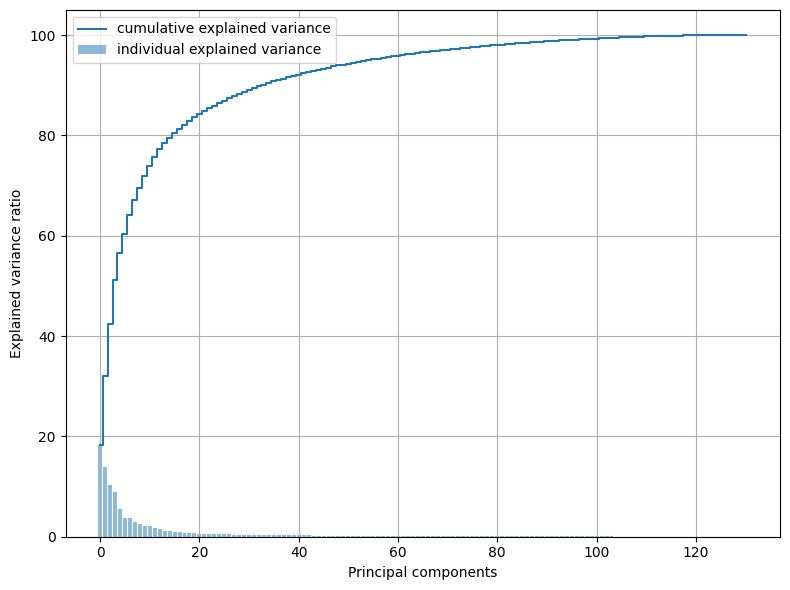

In [ ]:
# Calculate the participation in terms of %
tot = sum(np.diag(S))
var_exp = [(i / tot)*100 for i in sorted(np.diag(S), reverse=True)]
cum_var_exp = np.cumsum(var_exp)

# Plot the graph
plt.figure(figsize=(8, 6))
plt.bar(range(len(np.diag(S))), var_exp, alpha=0.5, align='center',
        label='individual explained variance')
plt.step(range(len(np.diag(S))), cum_var_exp, where='mid',
          label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()
plt.grid()
plt.show()

As you can see in graph above, by using the first 50 principal components we can keep almost the $90\%$ of the total variance. Let's take a look at the *mean face*

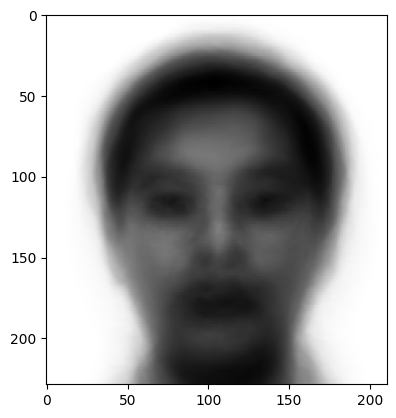

In [ ]:
# Define the number of principal components to keep
p = 50

# Keep only the first p principal directions
V_p = V[:, :p]
S_p = S[:p, :p]

# Plot the mean face
plt.figure()
plt.imshow(train_faces.mean(axis = 0).reshape(faces_shape), cmap = "gray")
plt.show()

And now build a big image with the 6 first principal directions


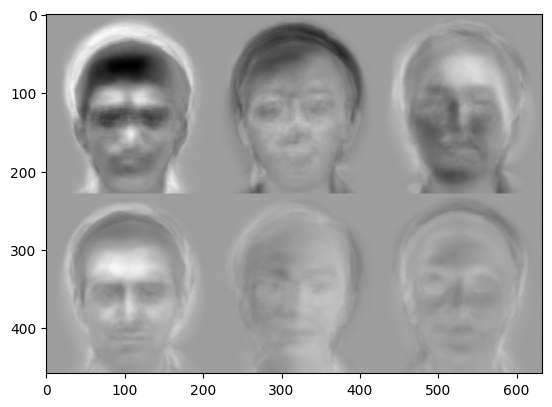

In [ ]:
# Build up the images array
num_rows = 2
num_columns = 3
tmp = np.empty(shape = (faces_shape[0] * num_rows, faces_shape[1] * num_columns))
component_index = 0
for row in range(num_rows):
    for column in range(num_columns):
        tmp[faces_shape[0] * row: faces_shape[0] * (row + 1), faces_shape[1] * column: faces_shape[1] * (column + 1)] = (S_p[component_index, component_index] * V_p[:, component_index]).reshape(faces_shape)
        component_index += 1

# Plot the images
plt.figure()
plt.imshow(tmp, cmap = "gray")
plt.show()

**5) project a test face over principal directions**

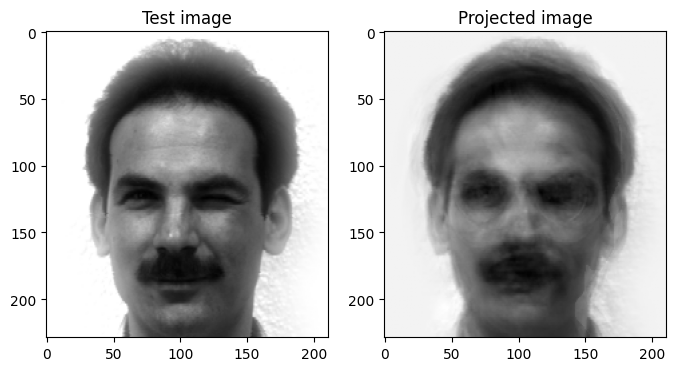

In [ ]:
# Keep one of the test faces
x = test_faces[0, :]

# Build up the principal components
_, z = pca_prin_comp(x = x, eigen_vectors = V_p, mu = train_faces.mean(axis = 0));

# Reconstruct the face
x_proj = pca_reconstruct(z = z, eigen_vectors = V_p, mean = train_faces.mean(axis = 0))

# Show both faces
fig, (ax1, ax2) = plt.subplots(figsize=(8, 6), ncols=2)
ax1.imshow(x.reshape(faces_shape), cmap = "gray")
ax1.set_title("Test image")
ax2.imshow(x_proj.reshape(faces_shape), cmap = "gray")
ax2.set_title("Projected image")
plt.show()

**6) Recognize faces**

This a very simple face recognition algorithm: it is based on comparing the PCA coordinages of a query face with those of the training set.

Showing image 1 of 33


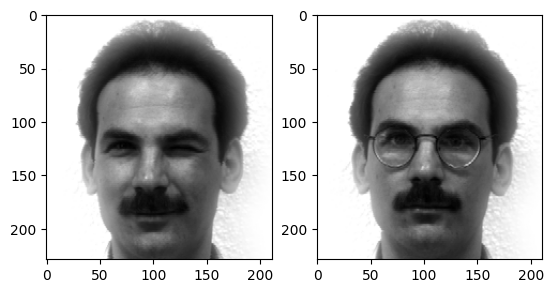

Showing image 2 of 33


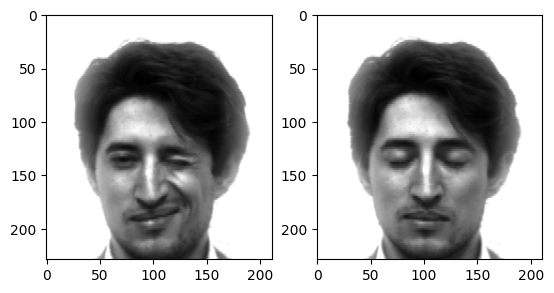

Showing image 3 of 33


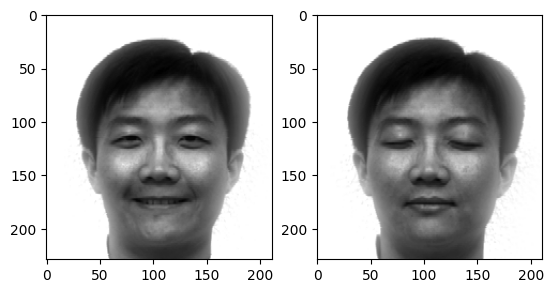

Showing image 4 of 33


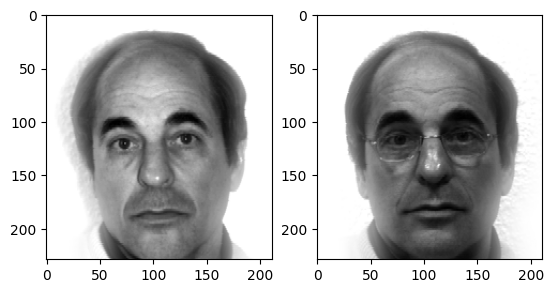

Showing image 5 of 33


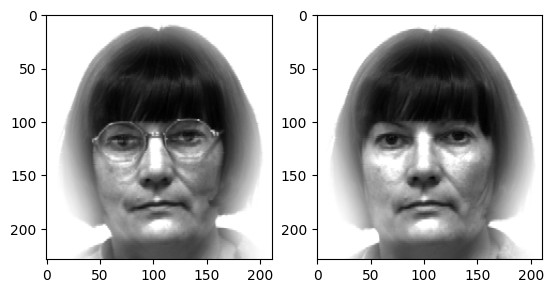

Showing image 6 of 33


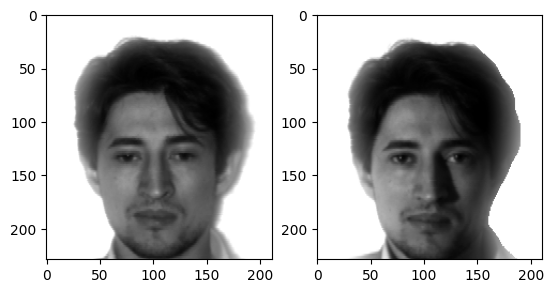

Showing image 7 of 33


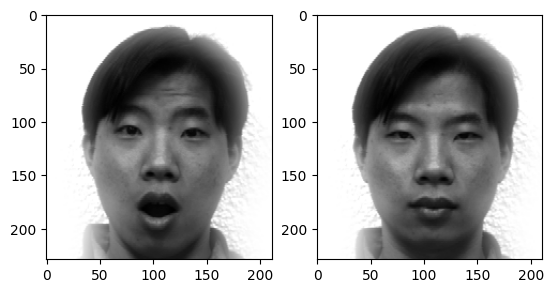

Showing image 8 of 33


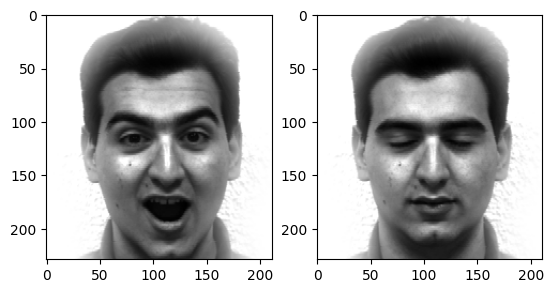

In [ ]:
# Import a library to simulate time steps
import time
%matplotlib inline

# Define the number of principal components to keep
p = 100

# Keep only the first p principal directions
V_p = V[:, :p]
S_p = S[:p, :p]

# Compute principal components for training faces
_, train_z = pca_prin_comp(x = train_faces, eigen_vectors = V_p, mu = train_faces.mean(axis = 0))

# Compute principal components for test faces
_, test_z = pca_prin_comp(x = test_faces, eigen_vectors = V_p, mu = train_faces.mean(axis = 0))

# Classify
nn_idx = []
for i in range(len(test_faces)):
    d = np.linalg.norm(np.tile(test_z[[i], :], (train_z.shape[0], 1)).T - train_z.T, axis = 0).T
    nn_idx.append(int(d.argmin()))

# Visualize classification results
plt.figure()
plt.ion()
for i in range(len(test_faces)):
    print("Showing image {} of {}".format(i + 1, len(test_faces)))
    plt.subplot(1, 2, 1).imshow(test_faces[i, :].reshape(faces_shape), cmap = "gray")
    ax1.set_title("Test image")
    plt.subplot(1, 2, 2).imshow(train_faces[nn_idx[i], :].reshape(faces_shape), cmap = "gray")
    ax2.set_title("Training image")
    plt.show()
    plt.pause(1)

<font color='red'>**ANSWER**

We can can clearly see by taking a quick look at the plot of the cumulative explained variance and individual that most of it is explained with just the first 50 components, the components are the eigenvectors of the data covariance matrix.

In order to calculate the mean face we know that our dataset consists of a matrix with flattened faces as rows and by calculating the mean of each column we end up with the mean face, giving the result in point 4.

When plotting the images of the first 6 directions we see kind of a spectrum of four different faces that correspond to the vectors pointing in the direction of the 6 first components.

In the part where we are projecting a face in the most important directions we can see that the result is considerably blurry, which makes sense because we are projecting a random face into different directions at the same time.

The last part implements a basic face recognition algorithm using PCA and nearest neighbor matching. First, it picks the top 100 principal components that have the directions with highest variance in the face dataset, then projects both training and test faces into this reduced dimension space. For each test face, it finds the training face with the smallest Euclidean distance in that PCA subspace, effectively identifying the closest similarity. Finally, it shows the test image alongside its nearest training image neighbor for visual confirmation.

<font color='blue'>**(QUESTION 2.5b)** Try changing the number of principal components used in step 6 and comment how this affects to the number of classification errors.

<font color='red'>**ANSWER**

The more we increase the number of principal components, the accuracy of the model generally increases. However, when the number of components becomes very large, I noticed a decrease in accuracy, possibly because the model becomes too sensitive to small differences or noise. On the other hand, when using a small number of components, the model performs poorly because it only captures general patterns and lacks the precision to distinguish between similar faces.